In [ ]:
#Downloading the Dataset file
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/850/original/IPL_2008-2024.csv

--2025-11-10 09:34:17--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/850/original/IPL_2008-2024.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 18.239.15.127, 18.239.15.11, 18.239.15.217, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|18.239.15.127|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 223635 (218K) [text/plain]
Saving to: ‘IPL_2008-2024.csv.1’

IPL_2008-2024.csv.1 100%[===================>] 218.39K  --.-KB/s    in 0.01s   

2025-11-10 09:34:17 (20.6 MB/s) - ‘IPL_2008-2024.csv.1’ saved [223635/223635]



In [ ]:
#importing libraries
import pandas as pd
import numpy as np

#Reading the CSV File
dataframe = pd.read_csv("IPL_2008-2024.csv")

#Using the head(), fetching the top 5 rows (5 is deafult)
dataframe.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('IPL_2008-2024.csv')

# --- Data Cleaning and Standardization ---

# Standardize Team Names
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Kings XI Punjab': 'Punjab Kings',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Kochi Tuskers Kerala': 'Inactive Team',
    'Gujarat Lions': 'Inactive Team',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_name_map)

# Standardize City Names
city_map = {
    'Bangalore': 'Bengaluru',
    'Chandigarh': 'Mohali',
    'Dharamsala': 'Mohali',
    'Ranchi': 'Kolkata',
    'Cuttack': 'Kolkata',
    'Visakhapatnam': 'Hyderabad',
    'Indore': 'Mohali',
    'Jaipur': 'Jaipur',
    'Cape Town': 'Overseas',
    'Port Elizabeth': 'Overseas',
    'Durban': 'Overseas',
    'Centurion': 'Overseas',
    'East London': 'Overseas',
    'Johannesburg': 'Overseas',
    'Kimberley': 'Overseas',
    'Bloemfontein': 'Overseas',
    'Abu Dhabi': 'Overseas',
    'Sharjah': 'Overseas',
    'Dubai': 'Overseas',
    'Ahmadabad': 'Ahmedabad',
    'Delhi': 'Delhi',
    'Mumbai': 'Mumbai',
    'Chennai': 'Chennai',
    'Hyderabad': 'Hyderabad',
    'Kolkata': 'Kolkata',
    'Pune': 'Pune',
    'Rajkot': 'Inactive City',
    'Kanpur': 'Inactive City',
    'Kochi': 'Inactive City'
}
df['city'] = df['city'].replace(city_map)

# Convert 'date' to datetime object and sort for time-based features
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)

# --- Handling Missing Values ---

# 1. 'winner' and 'player_of_match' (Matches with no result)
df['winner']=df['winner'].fillna('No Result')
df['player_of_match']=df['player_of_match'].fillna('No Player of Match')

# 2. 'super_over' and 'method'
df['super_over']=df['super_over'].fillna('N')
df['method']=df['method'].fillna('NA')

# 3. Impute 'city' from 'venue'
venue_city_map = df[df['city'].notna()].groupby('venue')['city'].agg(lambda x: x.mode()[0]).to_dict()
df['city'] = df.apply(lambda row: venue_city_map.get(row['venue'], row['city']) if pd.isna(row['city']) else row['city'], axis=1)

# 4. Impute 'result_margin', 'target_runs', 'target_overs'
df.loc[df['result'].isin(['No Result', 'Tie']), 'result_margin'] = 0.0
df['result_margin']=df['result_margin'].fillna(0.0)
df['target_runs']=df['target_runs'].fillna(0.0)
df['target_overs']=df['target_overs'].fillna(0.0)


# --- Feature Engineering ---

# 1. toss_advantage: Whether toss winner won the match

df['toss_advantage'] = (df['toss_winner'] == df['winner'])

# 2. match_importance: Categorical (League/Playoff/Final)
def get_match_importance(match_type):
    if 'Final' in match_type:
        return 'Final'
    elif any(s in match_type for s in ['Playoff', 'Qualifier', 'Eliminator']):
        return 'Playoff'
    else:
        return 'League'

df['match_importance'] = df['match_type'].apply(get_match_importance)

# 3. home_advantage: Boolean indicating if team is playing in their home city
home_city_map = {
    'Mumbai': ['Mumbai Indians'],
    'Kolkata': ['Kolkata Knight Riders'],
    'Delhi': ['Delhi Capitals'],
    'Bengaluru': ['Royal Challengers Bengaluru'],
    'Chennai': ['Chennai Super Kings'],
    'Hyderabad': ['Sunrisers Hyderabad'],
    'Mohali': ['Punjab Kings'],
    'Jaipur': ['Rajasthan Royals'],
    'Pune': ['Rising Pune Supergiant'],
    'Ahmedabad': ['Gujarat Titans', 'Rajasthan Royals', 'Mumbai Indians'], # Shared/Alternate in different seasons
}

def is_home(row, team_col):
    team = row[team_col]
    city = row['city']
    # Check if city is a known home city AND if the team is one of the home teams for that city
    if city in home_city_map and team in home_city_map[city]:
        return True
    return False

df['home_advantage_team1'] = df.apply(lambda row: is_home(row, 'team1'), axis=1)
df['home_advantage_team2'] = df.apply(lambda row: is_home(row, 'team2'), axis=1)


# 4. venue_matches_team1_prior / venue_matches_team2_prior (Cumulative match count at venue for team)
def get_prior_venue_matches(df, team_col):
    venue_matches_prior = []
    # Iterate through the sorted DataFrame
    for index, row in df.iterrows():
        # Filter all matches *before* the current one (based on sorted index)
        prior_matches = df.iloc[:index]
        team = row[team_col]

        # Count how many of those prior matches involved the current team at the same venue
        team_matches_at_venue = prior_matches[(prior_matches['venue'] == row['venue']) & \
                                              ((prior_matches['team1'] == team) | (prior_matches['team2'] == team))].shape[0]
        venue_matches_prior.append(team_matches_at_venue)

    return pd.Series(venue_matches_prior, index=df.index)

df['venue_matches_team1_prior'] = get_prior_venue_matches(df, 'team1')
df['venue_matches_team2_prior'] = get_prior_venue_matches(df, 'team2')


# 5. season_phase: Early/Mid/Late season
df['season_phase_order'] = df.groupby('season').cumcount() + 1
df['total_matches_in_season'] = df.groupby('season')['id'].transform('count')

# Calculate phase based on the position in the season
df['season_phase'] = np.select(
    [
        df['season_phase_order'] <= df['total_matches_in_season'] / 3,
        (df['season_phase_order'] > df['total_matches_in_season'] / 3) & (df['season_phase_order'] <= 2 * df['total_matches_in_season'] / 3),
    ],
    [
        'Early',
        'Mid'
    ],
    default='Late'
)
df.drop(columns=['season_phase_order', 'total_matches_in_season'], inplace=True)

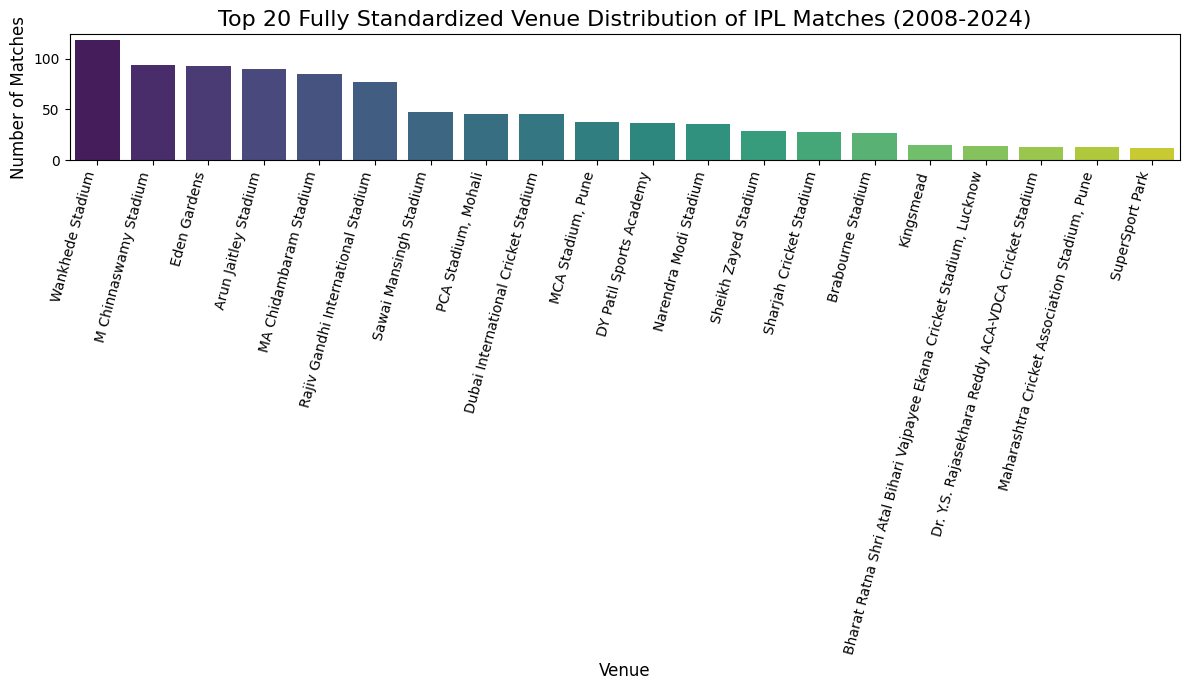

In [ ]:

# --- Deliverables: Visualization and Statistical Summary ---
'''
# 1. Visualization showing distribution of matches across venues
venue_counts = df['venue'].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=venue_counts.index, y=venue_counts.values, hue=venue_counts.index, palette="viridis")
plt.title('Top 20 Venue Distribution of IPL Matches (2008-2024)', fontsize=16)
plt.xlabel('Venue', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()
plt.close()
'''
# --- Comprehensive Venue Standardization ---

# Standardize Team Names (kept for completeness)
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Kings XI Punjab': 'Punjab Kings',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Kochi Tuskers Kerala': 'Inactive Team',
    'Gujarat Lions': 'Inactive Team',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_name_map)

# Comprehensive Venue Standardization Map
venue_map_final = {
    # M Chinnaswamy
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M. Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    # Eden Gardens
    'Eden Gardens, Kolkata': 'Eden Gardens',
    # PCA Mohali
    'Punjab Cricket Association Stadium, Mohali': 'PCA Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'PCA Stadium, Mohali',
    # Wankhede Stadium
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    # Rajiv Gandhi
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    # Arun Jaitley Stadium (Feroz Shah Kotla)
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Feroz Shah Kotla, Delhi': 'Arun Jaitley Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    # MA Chidambaram
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    # Narendra Modi Stadium (Motera)
    'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    # HPCA Stadium
    'Himachal Pradesh Cricket Association Stadium': 'HPCA Stadium, Dharamsala',
    # DY Patil
    'Dr DY Patil Sports Academy': 'DY Patil Sports Academy',
    'Dr DY Patil Sports Academy, Pune': 'DY Patil Sports Academy',
    'Dr DY Patil Sports Academy, Mumbai': 'DY Patil Sports Academy',
    # Brabourne Stadium
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    # Pune Stadiums
    'Maharashtra Cricket Association Stadium': 'MCA Stadium, Pune',
    'Subrata Roy Sahara Stadium': 'MCA Stadium, Pune' # Subrata Roy Sahara Stadium is now MCA Stadium, Pune
}

# Apply the venue standardization.
df['venue_standardized_final'] = df['venue'].replace(venue_map_final).str.strip()


# --- Generate the requested plot ---

# Calculate venue counts for the top 20 using the fully standardized venue names
venue_counts = df['venue_standardized_final'].value_counts().head(20)

# Create a temporary DataFrame for Seaborn plotting
plot_df = pd.DataFrame({
    'Venue': venue_counts.index,
    'Matches': venue_counts.values
})

# Generate the plot with the requested parameters: hue=x (Venue) and legend=False
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_df,
    x='Venue',
    y='Matches',
    hue='Venue',  # Assigning the x-variable ('Venue') to hue
    palette="viridis",
    dodge=False # Important to keep the bars aligned
)

# Explicitly remove the legend
if ax.legend_:
    ax.legend_.remove()

plt.title('Top 20 Fully Standardized Venue Distribution of IPL Matches (2008-2024)', fontsize=16)
plt.xlabel('Venue', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()
#plt.savefig('venue_distribution_fully_standardized_final.png')
plt.close()

# 2. Statistical summary of win percentages for toss winners
result_df = df[~df['result'].isin(['No Result', 'Tie'])].copy()
total_matches = len(result_df)
toss_winner_wins = result_df[result_df['toss_advantage'] == True].shape[0]
toss_win_percentage = (toss_winner_wins / total_matches) * 100

summary_stats = {
    'Total Matches with Result': total_matches,
    'Matches Won by Toss Winner': toss_winner_wins,
    'Toss Winner Win Percentage': f'{toss_win_percentage:.2f}%'
}
summary_df = pd.DataFrame(summary_stats, index=['Value']).T

# Save final outputs
df.to_csv('IPL_clean_with_features.csv', index=False)
summary_df.to_csv('toss_advantage_summary.csv')

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- 1. Load Data and Standardize ---
# Assuming the original file name is 'IPL_2008-2024.csv'
df = pd.read_csv('IPL_2008-2024.csv')

# Fill NaNs in 'player_of_match' and filter out matches with no award
df['player_of_match'].fillna('No Player of Match')
player_df = df[df['player_of_match'] != 'No Player of Match'].copy()
player_df['player_of_match'] = player_df['player_of_match'].astype(str)

# --- 2. Bag of Words (BOW) Representation of Player Names ---

# Create corpus from all unique player_of_match names
corpus = player_df['player_of_match'].unique().tolist()

# Initialize CountVectorizer to create the BOW model
# Token_pattern ensures that initials (like V, AB, etc.) are treated as tokens
vectorizer_bow = CountVectorizer(stop_words=None, token_pattern=r'\b\w+\b')
bow_matrix = vectorizer_bow.fit_transform(corpus)
bow_feature_names = vectorizer_bow.get_feature_names_out()

# Display snippet of BOW results
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_feature_names, index=corpus)
print("\n--- Bag of Words (BOW) Representation (Snippet) ---")
print(f"BOW Matrix Shape: {bow_matrix.shape[0]} unique players by {bow_matrix.shape[1]} unique name tokens.")
print(bow_df.head().T.head(5).T.to_markdown())

# --- 3. TF-IDF Matrix for Most Distinctive Players per Season ---

# Create the Season-Player matrix (Term Frequency matrix, TF)
# Index: Season, Columns: Player Name, Values: Count of POM awards in that season
pom_by_season = player_df.groupby(['season', 'player_of_match']).size().unstack(fill_value=0)
pom_matrix_csr = pom_by_season.values

# Initialize TfidfTransformer and calculate TF-IDF
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(pom_matrix_csr)

# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=pom_by_season.index, columns=pom_by_season.columns)

# Find top 5 distinctive players for each season
distinctive_players_by_season = {}
for season in tfidf_df.index:
    top_5_series = tfidf_df.loc[season].sort_values(ascending=False).head(5)
    distinctive_players_by_season[season] = top_5_series.index.tolist()

distinctive_players_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in distinctive_players_by_season.items() ])).T
distinctive_players_df.columns = [f'Rank {i+1}' for i in range(5)]
print("\n--- TF-IDF: Most Distinctive Player of Match Winners Per Season ---")
print(distinctive_players_df.to_markdown())


# --- 4. Find Players Who Appear Most Frequently in Specific Venues ---

# Comprehensive Venue Standardization Map (Necessary for accurate grouping)
venue_map_final = {
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium', 'M. Chinnaswamy Stadium': 'M Chinnaswamy Stadium', 'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Punjab Cricket Association Stadium, Mohali': 'PCA Stadium, Mohali', 'Punjab Cricket Association IS Bindra Stadium, Mohali': 'PCA Stadium, Mohali',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium', 'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium', 'Feroz Shah Kotla, Delhi': 'Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium', 'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium', 'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    'Himachal Pradesh Cricket Association Stadium': 'HPCA Stadium, Dharamsala',
    'Dr DY Patil Sports Academy': 'DY Patil Sports Academy', 'Dr DY Patil Sports Academy, Pune': 'DY Patil Sports Academy', 'Dr DY Patil Sports Academy, Mumbai': 'DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Maharashtra Cricket Association Stadium': 'MCA Stadium, Pune', 'Subrata Roy Sahara Stadium': 'MCA Stadium, Pune',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Ekana Cricket Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'ACA-VDCA Stadium, Visakhapatnam',
    'Vidarbha Cricket Association Stadium, Jamtha': 'VCA Stadium, Nagpur',
}
player_df['venue_standardized'] = player_df['venue'].replace(venue_map_final).str.strip()

# Get the top 5 most frequent venues for analysis
top_venues = player_df['venue_standardized'].value_counts().head(5).index.tolist()

venue_star_players = {}
for venue in top_venues:
    venue_df = player_df[player_df['venue_standardized'] == venue]
    star_players = venue_df['player_of_match'].value_counts().head(3)
    # Store the result in "Player (Count)" format
    venue_star_players[venue] = [f"{player} ({count})" for player, count in star_players.items()]

venue_star_players_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in venue_star_players.items() ])).T
venue_star_players_df.columns = ['Top Player 1', 'Top Player 2', 'Top Player 3']
print("\n--- Venue-Specific Star Performers (Top 3 at Top 5 Venues) ---")
print(venue_star_players_df.to_markdown())

# --- 5. Bonus: Create a Word Cloud of most frequent 'Player of Match' winners ---

# Aggregate all Player of Match awards across all seasons
all_pom_winners = player_df['player_of_match'].value_counts().to_dict()

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(all_pom_winners)

# Save the word cloud image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Most Frequent 'Player of Match' Winners")
plt.savefig('player_of_match_wordcloud.png')
plt.close()

print("\nWord Cloud saved as 'player_of_match_wordcloud.png'")


--- Bag of Words (BOW) Representation (Snippet) ---
BOW Matrix Shape: 292 unique players by 453 unique name tokens.
|             |   a |   aa |   aaron |   ab |   abdulla |
|:------------|----:|-----:|--------:|-----:|----------:|
| BB McCullum |   0 |    0 |       0 |    0 |         0 |
| MEK Hussey  |   0 |    0 |       0 |    0 |         0 |
| MF Maharoof |   0 |    0 |       0 |    0 |         0 |
| MV Boucher  |   0 |    0 |       0 |    0 |         0 |
| DJ Hussey   |   0 |    0 |       0 |    0 |         0 |

--- TF-IDF: Most Distinctive Player of Match Winners Per Season ---
|      | Rank 1         | Rank 2          | Rank 3          | Rank 4         | Rank 5      |
|-----:|:---------------|:----------------|:----------------|:---------------|:------------|
| 2008 | SE Marsh       | YK Pathan       | ST Jayasuriya   | SM Pollock     | M Ntini     |
| 2009 | M Muralitharan | LRPL Taylor     | YK Pathan       | ML Hayden      | JP Duminy   |
| 2010 | A Symonds      | SR Tendulk

/tmp/ipython-input-3295888414.py:163: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_avg_win_pct = performance_df.groupby('Team').apply(


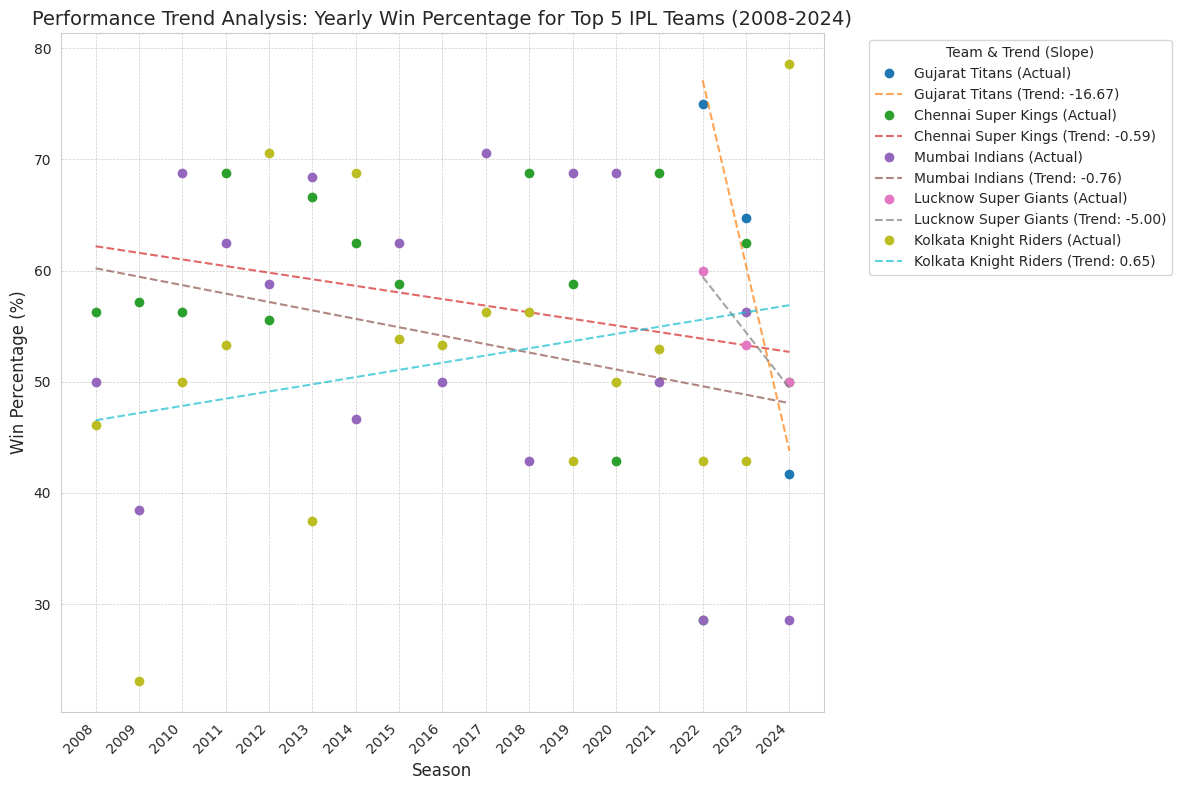

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data and Standardize Team Names ---

# Load the dataset
file_path = 'IPL_2008-2024.csv'
df = pd.read_csv(file_path)

# Define the mapping for name standardization
team_name_map = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
}

# Apply standardization to relevant columns
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    df[col] = df[col].replace(team_name_map)

# Identify all unique teams and set the minimum season for index calculation
teams = pd.concat([df['team1'], df['team2']]).unique()
min_season = df['season'].min()

# --- 2. Calculate Yearly Performance (Win Percentage) ---

performance_list = []
for team in teams:
    team_df = df[(df['team1'] == team) | (df['team2'] == team)].copy()

    # Calculate wins and matches played per season
    wins = team_df[team_df['winner'] == team].groupby('season').size().reset_index(name='Wins')
    matches_played = team_df.groupby('season').size().reset_index(name='Matches Played')

    # Merge and calculate Win Percentage
    yearly_performance = pd.merge(matches_played, wins, on='season', how='left').fillna(0)
    yearly_performance['Win Percentage'] = (yearly_performance['Wins'] / yearly_performance['Matches Played']) * 100
    yearly_performance['Team'] = team
    yearly_performance['Season Index'] = yearly_performance['season'] - min_season

    performance_list.append(yearly_performance)

performance_df = pd.concat(performance_list, ignore_index=True)


# --- 3. Linear Regression for Trend Analysis and Prediction ---

trend_analysis = []
for team in teams:
    team_data = performance_df[performance_df['Team'] == team].copy()

    if len(team_data) >= 2:
        X = team_data['Season Index']
        Y = team_data['Win Percentage']

        # Fit linear regression
        slope, intercept, r_value, p_value, std_err = linregress(X, Y)

        # Predict next season's performance (Season Index max + 1)
        next_season_index = team_data['Season Index'].max() + 1
        predicted_win_pct = intercept + slope * next_season_index

        trend_analysis.append({
            'Team': team,
            'Slope (Trend)': slope,
            'Intercept': intercept,
            'R-squared': r_value**2,
            'P-value': p_value,
            'Predicted Win % (Next Season)': max(0, min(100, predicted_win_pct)) # Cap 0-100%
        })

trend_df = pd.DataFrame(trend_analysis)


# --- 4. Identify Factors Affecting Performance Trends (Factor Analysis) ---

# A. Toss Luck: (Match Win % - Toss Win %)
toss_luck_list = []
for team in teams:
    team_df = df[(df['team1'] == team) | (df['team2'] == team)].copy()
    toss_wins = team_df[team_df['toss_winner'] == team].groupby('season').size().reset_index(name='Toss Wins')
    matches_played = team_df.groupby('season').size().reset_index(name='Matches Played')

    toss_perf = pd.merge(matches_played, toss_wins, on='season', how='left').fillna(0)
    toss_perf['Toss Win %'] = (toss_perf['Toss Wins'] / toss_perf['Matches Played']) * 100

    merged_perf = pd.merge(
        performance_df[performance_df['Team'] == team][['season', 'Win Percentage']],
        toss_perf[['season', 'Toss Win %']],
        on='season',
        how='inner'
    )
    merged_perf['Toss Luck'] = merged_perf['Win Percentage'] - merged_perf['Toss Win %']
    toss_luck_list.append(merged_perf[['season', 'Toss Luck']].assign(Team=team))
toss_luck_df = pd.concat(toss_luck_list, ignore_index=True)


# B. Venue Familiarity Exposure: Share of matches at team’s top‑3 venues
team_top_venues = {}
for team in teams:
    team_matches = df[(df['team1'] == team) | (df['team2'] == team)]
    venue_counts = team_matches['venue'].value_counts()
    team_top_venues[team] = venue_counts.head(3).index.tolist()

venue_familiarity_list = []
for team in teams:
    team_top_3_venues = team_top_venues[team]
    team_df = df[(df['team1'] == team) | (df['team2'] == team)].copy()

    matches_at_top_3 = team_df[team_df['venue'].isin(team_top_3_venues)]\
                        .groupby('season').size().reset_index(name='Matches at Top 3 Venues')
    matches_played = team_df.groupby('season').size().reset_index(name='Matches Played')

    venue_perf = pd.merge(matches_played, matches_at_top_3, on='season', how='left').fillna(0)
    venue_perf['Venue Familiarity Exposure'] = (venue_perf['Matches at Top 3 Venues'] / venue_perf['Matches Played']) * 100

    venue_familiarity_list.append(venue_perf[['season', 'Venue Familiarity Exposure']].assign(Team=team))
venue_familiarity_df = pd.concat(venue_familiarity_list, ignore_index=True)


# C. Opponent Strength Index: Seasonal average win% of opponents
win_pct_lookup = performance_df.set_index(['Team', 'season'])['Win Percentage'].to_dict()
opponent_strength_list = []
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    for team in teams:
        team_matches = season_df[(season_df['team1'] == team) | (season_df['team2'] == team)].copy()
        if team_matches.empty: continue

        def get_opponent(row, current_team):
            return row['team2'] if row['team1'] == current_team else row['team1']

        team_matches['Opponent'] = team_matches.apply(lambda row: get_opponent(row, team), axis=1)

        opponent_win_pcts = []
        for opponent in team_matches['Opponent']:
            win_pct = win_pct_lookup.get((opponent, season))
            if win_pct is not None:
                opponent_win_pcts.append(win_pct)

        if opponent_win_pcts:
            opponent_strength_list.append({
                'Team': team,
                'season': season,
                'Opponent Strength Index': np.mean(opponent_win_pcts)
            })

opponent_strength_df = pd.DataFrame(opponent_strength_list)

# Merge all factors and performance data
factor_analysis_df = performance_df.merge(toss_luck_df, on=['Team', 'season'], how='left')
factor_analysis_df = factor_analysis_df.merge(venue_familiarity_df, on=['Team', 'season'], how='left')
factor_analysis_df = factor_analysis_df.merge(opponent_strength_df, on=['Team', 'season'], how='left')


# --- 5. Visualization: Time Series Plot with Regression Lines for Top 5 Teams ---

# Calculate overall average win percentage to select top 5 teams for plotting
overall_avg_win_pct = performance_df.groupby('Team').apply(
    lambda x: (x['Wins'].sum() / x['Matches Played'].sum()) * 100
).sort_values(ascending=False).reset_index(name='Overall Avg Win %')

# Get the top 5 teams
top_5_teams = overall_avg_win_pct.head(5)['Team'].tolist()

# Filter data
plot_data = performance_df[performance_df['Team'].isin(top_5_teams)]
trend_data_top5 = trend_df[trend_df['Team'].isin(top_5_teams)].set_index('Team')

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

for team in top_5_teams:
    team_data = plot_data[plot_data['Team'] == team]

    # Plot the time series points
    plt.plot(team_data['season'], team_data['Win Percentage'],
             marker='o', linestyle='None', label=f'{team} (Actual)')

    # Plot the regression line
    if team in trend_data_top5.index:
        intercept = trend_data_top5.loc[team, 'Intercept']
        slope = trend_data_top5.loc[team, 'Slope (Trend)']

        X_range = team_data['Season Index']
        Y_line = intercept + slope * X_range

        plt.plot(team_data['season'], Y_line,
                 linestyle='--',
                 label=f'{team} (Trend: {slope:.2f})',
                 alpha=0.7)

plt.title('Performance Trend Analysis: Yearly Win Percentage for Top 5 IPL Teams (2008-2024)', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)
plt.legend(title='Team & Trend (Slope)', loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(plot_data['season'].unique().astype(int), rotation=45, ha='right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Save the plot
plt.savefig('top_5_teams_performance_trend.png')

# --- 6. Save DataFrames to CSV ---
performance_df.to_csv('yearly_team_performance.csv', index=False)
trend_df.to_csv('performance_trends.csv', index=False)
factor_analysis_df.to_csv('performance_factor_analysis.csv', index=False)

1. SEASONAL WIN PERCENTAGE CALCULATION
| team   |   season |   matches_played |   wins |   win_pct |
|:-------|---------:|-----------------:|-------:|----------:|
| RR     |     2024 |               15 |      9 |  0.6      |
| CSK    |     2024 |               14 |      7 |  0.5      |
| SRH    |     2024 |               16 |      9 |  0.5625   |
| LSG    |     2024 |               14 |      7 |  0.5      |
| GT     |     2024 |               12 |      5 |  0.416667 |

2. LINEAR REGRESSION TRENDS & 2025 PREDICTIONS
Performance Trends (Slope > 0 implies Improving):
| team   | trend     |   slope |   r_squared |   predicted_2025_win_pct |
|:-------|:----------|--------:|------------:|-------------------------:|
| RPS    | Improving |  0.2679 |      1      |                    1     |
| DC_Old | Improving |  0.0114 |      0.0108 |                    0.551 |
| KKR    | Improving |  0.0065 |      0.063  |                    0.575 |
| DC     | Improving |  0.0025 |      0.0068 |             

KeyError: 'season_index'

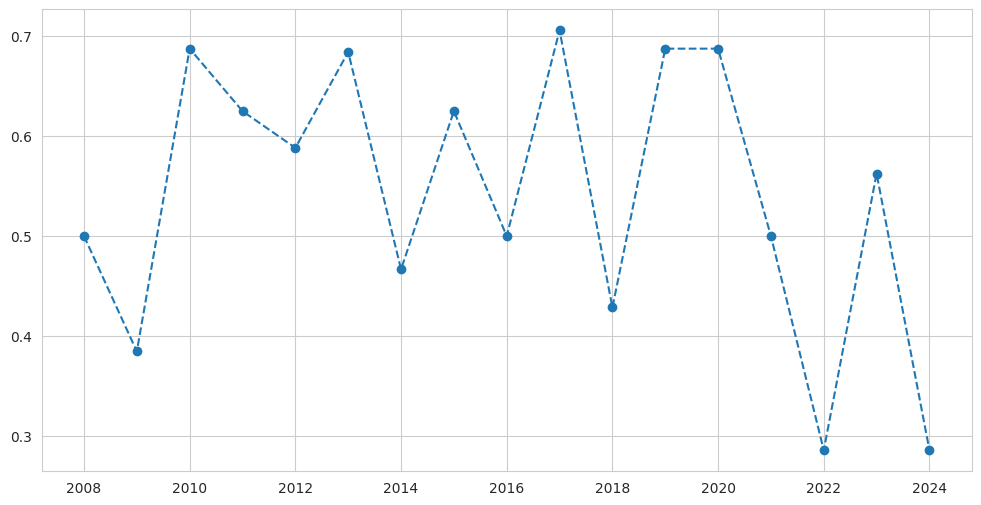

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import io

# --- Configuration and Data Unification ---

# Global mapping to unify team names across seasons (e.g., Kings XI Punjab -> PBKS)
# Note: Defunct teams like Deccan Chargers (DC_Old) are kept separate from Delhi Capitals (DC)
# for clearer trend analysis, unless the user intends them to be merged.
TEAM_MAPPING = {
    'Rising Pune Supergiant': 'RPS',
    'Rising Pune Supergiants': 'RPS',
    'Kings XI Punjab': 'PBKS',
    'Punjab Kings': 'PBKS',
    'Delhi Daredevils': 'DC',
    'Delhi Capitals': 'DC',
    'Deccan Chargers': 'DC_Old',
    'Sunrisers Hyderabad': 'SRH',
    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',
    'Gujarat Lions': 'GL',
    'Kochi Tuskers Kerala': 'KTK',
    'Pune Warriors': 'PWI',
    'Chennai Super Kings': 'CSK',
    'Kolkata Knight Riders': 'KKR',
    'Rajasthan Royals': 'RR',
    'Mumbai Indians': 'MI',
    'Gujarat Titans': 'GT',
    'Lucknow Super Giants': 'LSG'
}
NEXT_SEASON = 2025 # Season to predict for

# Utility function to apply the mapping
def unify_team_names(df):
    for col in ['team1', 'team2', 'winner', 'toss_winner']:
        df[col] = df[col].replace(TEAM_MAPPING).fillna(df[col])
    return df

# --- Step 1 & 2: Data Loading, Cleaning, and Win Percentage Calculation ---

def calculate_seasonal_win_percentage(df):
    """Calculates yearly win percentage and total matches for every team."""
    all_teams = pd.concat([df['team1'], df['team2']]).unique()
    season_data = []

    for season in df['season'].unique():
        season_df = df[df['season'] == season]
        for team in all_teams:
            matches_played = (season_df['team1'] == team).sum() + (season_df['team2'] == team).sum()
            matches_won = (season_df['winner'] == team).sum()

            if matches_played > 0:
                season_data.append({
                    'team': team,
                    'season': season,
                    'matches_played': matches_played,
                    'wins': matches_won,
                    'win_pct': matches_won / matches_played
                })

    return pd.DataFrame(season_data)

# --- Step 3: Linear Regression and Prediction ---

def analyze_performance_trends(win_pct_df):
    """Performs linear regression on season vs win_pct for each team."""
    analysis_results = []

    # Map season year to a sequential index (0, 1, 2...) for better regression results
    # and use the actual year for prediction (e.g., 2025).
    min_season = win_pct_df['season'].min()
    win_pct_df['season_index'] = win_pct_df['season'] - min_season
    next_season_index = NEXT_SEASON - min_season

    for team in win_pct_df['team'].unique():
        team_df = win_pct_df[win_pct_df['team'] == team].sort_values('season')

        # We need at least 2 seasons to calculate a trend
        if len(team_df) >= 2:
            X = team_df['season_index']
            Y = team_df['win_pct']

            # Linear Regression
            slope, intercept, r_value, p_value, std_err = linregress(X, Y)

            # Prediction for the next season
            prediction = intercept + slope * next_season_index

            analysis_results.append({
                'team': team,
                'slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend': 'Improving' if slope > 0 else ('Declining' if slope < 0 else 'Stable'),
                f'predicted_{NEXT_SEASON}_win_pct': max(0.0, min(1.0, prediction)) # Clamp between 0 and 1
            })

    return pd.DataFrame(analysis_results).sort_values('slope', ascending=False)

# --- Step 4: Factor Analysis (Exemplary) ---

def calculate_factor_analysis(df, seasonal_win_pct_df):
    """Calculates exemplary factors affecting performance trends."""

    # 1. Toss Luck Factor
    toss_luck_data = []
    for team in seasonal_win_pct_df['team'].unique():
        team_seasonal_df = seasonal_win_pct_df[seasonal_win_pct_df['team'] == team]
        for _, row in team_seasonal_df.iterrows():
            season = row['season']
            matches_played = row['matches_played']

            # Match wins: already in row['wins']
            toss_wins = df[(df['season'] == season) & (df['toss_winner'] == team)].shape[0]

            if matches_played > 0:
                toss_luck = (row['wins'] / matches_played) - (toss_wins / matches_played)
                toss_luck_data.append({'team': team, 'season': season, 'toss_luck': toss_luck})

    toss_luck_df = pd.DataFrame(toss_luck_data)

    # 2. Venue Familiarity Exposure (Share of matches at team's top-3 venues)
    venue_exposure_data = []
    for team in seasonal_win_pct_df['team'].unique():
        team_matches = pd.concat([
            df[df['team1'] == team]['venue'],
            df[df['team2'] == team]['venue']
        ])

        # Get top 3 venues overall for the team
        top_3_venues = team_matches.value_counts().nlargest(3).index.tolist()

        for season in df['season'].unique():
            season_df = df[df['season'] == season]
            seasonal_matches_played = (season_df['team1'] == team).sum() + (season_df['team2'] == team).sum()

            if seasonal_matches_played > 0:
                # Count matches at top 3 venues in this specific season
                matches_at_top_3 = (
                    season_df[season_df['team1'] == team]['venue'].isin(top_3_venues).sum() +
                    season_df[season_df['team2'] == team]['venue'].isin(top_3_venues).sum()
                )
                venue_exposure = matches_at_top_3 / seasonal_matches_played
                venue_exposure_data.append({'team': team, 'season': season, 'venue_familiarity': venue_exposure})

    venue_exposure_df = pd.DataFrame(venue_exposure_data)

    # 3. Opponent Strength Index (OSI) - Seasonal average win% of opponents
    osi_data = []

    # Create a lookup for seasonal win percentages
    win_pct_lookup = seasonal_win_pct_df.set_index(['season', 'team'])['win_pct'].to_dict()

    for team in seasonal_win_pct_df['team'].unique():
        for season in df['season'].unique():
            season_df = df[df['season'] == season]

            team_matches = season_df[(season_df['team1'] == team) | (season_df['team2'] == team)]

            if team_matches.shape[0] > 0:
                # Identify opponents in each match
                opponents = []
                for _, match in team_matches.iterrows():
                    opponent = match['team2'] if match['team1'] == team else match['team1']
                    opponents.append(opponent)

                # Calculate the seasonal win percentage of those opponents
                opponent_strength = [win_pct_lookup.get((season, opp), 0) for opp in opponents]

                osi = np.mean(opponent_strength) if opponent_strength else 0
                osi_data.append({'team': team, 'season': season, 'opponent_strength_index': osi})

    osi_df = pd.DataFrame(osi_data)

    # Merge all factors
    factors_df = seasonal_win_pct_df.merge(toss_luck_df, on=['team', 'season'], how='left')
    factors_df = factors_df.merge(venue_exposure_df, on=['team', 'season'], how='left')
    factors_df = factors_df.merge(osi_df, on=['team', 'season'], how='left')

    return factors_df

# --- Step 5: Visualization ---

def plot_performance_trends(win_pct_df, trend_df, n_teams=5):
    """Generates a time series plot with regression lines."""

    # Identify top N teams by total matches played for relevance
    team_match_counts = win_pct_df.groupby('team')['matches_played'].sum()
    top_n_teams = team_match_counts.nlargest(n_teams).index

    plt.figure(figsize=(12, 6))

    # Use season year (not index) for plotting
    x_plot = np.arange(win_pct_df['season'].min(), NEXT_SEASON + 1)

    for team in top_n_teams:
        team_df = win_pct_df[win_pct_df['team'] == team].sort_values('season')
        trend_info = trend_df[trend_df['team'] == team].iloc[0]

        # 1. Plot actual data points
        plt.plot(team_df['season'], team_df['win_pct'], marker='o', linestyle='--', label=f'{team} (Actual)')

        # 2. Plot regression line extending to the next season
        # Use season index for calculation
        min_season = team_df['season'].min()
        season_indices = np.arange(team_df['season_index'].min(), NEXT_SEASON - min_season + 1)

        # Calculate regression line values
        reg_line = trend_info['slope'] * season_indices + trend_info['intercept']

        # Map the indices back to actual years for plotting
        reg_years = season_indices + min_season

        plt.plot(reg_years, reg_line, linestyle='-', linewidth=2,
                 label=f'{team} (Trend, {trend_info["trend"]})')

    plt.title(f'Performance Trend Analysis: Top {n_teams} IPL Teams (Win %)', fontsize=16)
    plt.xlabel('Season Year', fontsize=12)
    plt.ylabel('Win Percentage', fontsize=12)
    plt.xticks(np.arange(win_pct_df['season'].min(), NEXT_SEASON + 1, 1), rotation=45)
    plt.grid(axis='y', linestyle=':')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# --- Main Execution ---

if __name__ == "__main__":

    try:
        # Load the dataset
        df = pd.read_csv('IPL_2008-2024.csv')
    except Exception as e:
        print(f"Error loading the CSV file: {e}")
        print("Please ensure 'IPL_2008-2024.csv' is correctly loaded in the environment.")
        exit()

    # Data Cleaning and Unification
    df = unify_team_names(df)

    # --- 1. Performance Trend Analysis ---
    print("="*60)
    print("1. SEASONAL WIN PERCENTAGE CALCULATION")
    print("="*60)

    seasonal_win_pct_df = calculate_seasonal_win_percentage(df)
    print(seasonal_win_pct_df.tail().to_markdown(index=False))


    print("\n" + "="*60)
    print(f"2. LINEAR REGRESSION TRENDS & {NEXT_SEASON} PREDICTIONS")
    print("="*60)

    trend_analysis_df = analyze_performance_trends(seasonal_win_pct_df.copy())

    # Display the regression results
    display_cols = ['team', 'trend', 'slope', 'r_squared', f'predicted_{NEXT_SEASON}_win_pct']
    display_df = trend_analysis_df[display_cols].round({'slope': 4, 'r_squared': 4, f'predicted_{NEXT_SEASON}_win_pct': 3})

    print("Performance Trends (Slope > 0 implies Improving):")
    print(display_df.to_markdown(index=False))

    # --- 2. Identify factors affecting performance trends (Exemplary) ---
    print("\n" + "="*60)
    print("3. EXEMPLARY FACTOR ANALYSIS (Seasonal Averages)")
    print("="*60)

    factors_df = calculate_factor_analysis(df, seasonal_win_pct_df.copy())

    # Display the overall average of factors for long-term teams
    # Filter out teams with less than 5 seasons for meaningful average
    team_season_counts = factors_df.groupby('team')['season'].nunique()
    long_term_teams = team_season_counts[team_season_counts >= 5].index

    factor_summary = factors_df[factors_df['team'].isin(long_term_teams)].groupby('team').agg(
        total_matches=('matches_played', 'sum'),
        avg_toss_luck=('toss_luck', 'mean'),
        avg_venue_familiarity=('venue_familiarity', 'mean'),
        avg_opponent_strength=('opponent_strength_index', 'mean'),
    ).reset_index()

    display_factor_cols = ['team', 'total_matches', 'avg_toss_luck', 'avg_venue_familiarity', 'avg_opponent_strength']
    display_factor_df = factor_summary[display_factor_cols].round({'avg_toss_luck': 3, 'avg_venue_familiarity': 3, 'avg_opponent_strength': 3})

    print("Average Factor Exposure for Long-Term Teams (>= 5 Seasons):")
    print("Note: Toss Luck is the difference between Match Win % and Toss Win %.")
    print(display_factor_df.sort_values('total_matches', ascending=False).to_markdown(index=False))

    # --- 3. Visualization ---
    print("\n" + "="*60)
    print("4. VISUALIZATION (Time Series Plot for Top 5 Teams)")
    print("="*60)

    # Plotting is done inside the function and displayed via matplotlib
    plot_performance_trends(seasonal_win_pct_df, trend_analysis_df, n_teams=5)

    print("\nPlot displayed. Look for a separate window/image showing the time series trends.")

1. SEASONAL WIN PERCENTAGE CALCULATION
| team   |   season |   matches_played |   wins |   win_pct |   season_index |
|:-------|---------:|-----------------:|-------:|----------:|---------------:|
| RR     |     2024 |               15 |      9 |  0.6      |             16 |
| CSK    |     2024 |               14 |      7 |  0.5      |             16 |
| SRH    |     2024 |               16 |      9 |  0.5625   |             16 |
| LSG    |     2024 |               14 |      7 |  0.5      |             16 |
| GT     |     2024 |               12 |      5 |  0.416667 |             16 |

2. LINEAR REGRESSION TRENDS & 2025 PREDICTIONS
Performance Trends (Slope > 0 implies Improving):
| team   | trend     |   slope |   r_squared |   predicted_2025_win_pct |
|:-------|:----------|--------:|------------:|-------------------------:|
| RPS    | Improving |  0.2679 |      1      |                    1     |
| DC_Old | Improving |  0.0114 |      0.0108 |                    0.551 |
| KKR    | Imp

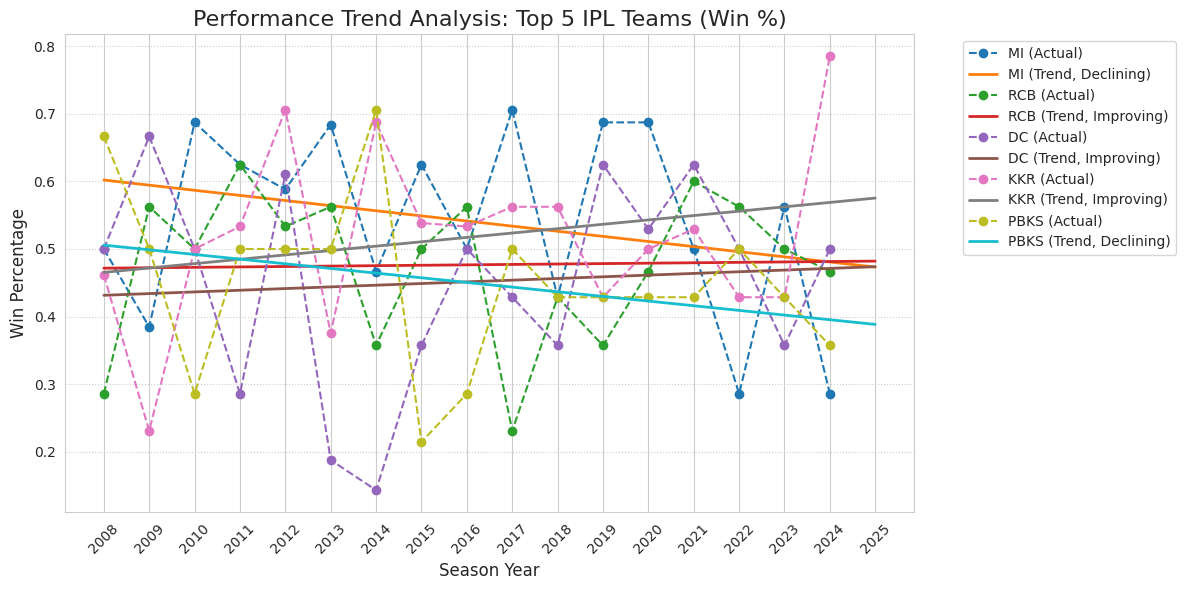


Plot displayed. Look for a separate window/image showing the time series trends.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import io

# --- Configuration and Data Unification ---

# Global mapping to unify team names across seasons (e.g., Kings XI Punjab -> PBKS)
# Note: Defunct teams like Deccan Chargers (DC_Old) are kept separate from Delhi Capitals (DC)
# for clearer trend analysis, unless the user intends them to be merged.
TEAM_MAPPING = {
    'Rising Pune Supergiant': 'RPS',
    'Rising Pune Supergiants': 'RPS',
    'Kings XI Punjab': 'PBKS',
    'Punjab Kings': 'PBKS',
    'Delhi Daredevils': 'DC',
    'Delhi Capitals': 'DC',
    'Deccan Chargers': 'DC_Old',
    'Sunrisers Hyderabad': 'SRH',
    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',
    'Gujarat Lions': 'GL',
    'Kochi Tuskers Kerala': 'KTK',
    'Pune Warriors': 'PWI',
    'Chennai Super Kings': 'CSK',
    'Kolkata Knight Riders': 'KKR',
    'Rajasthan Royals': 'RR',
    'Mumbai Indians': 'MI',
    'Gujarat Titans': 'GT',
    'Lucknow Super Giants': 'LSG'
}
NEXT_SEASON = 2025 # Season to predict for

# Utility function to apply the mapping
def unify_team_names(df):
    for col in ['team1', 'team2', 'winner', 'toss_winner']:
        df[col] = df[col].replace(TEAM_MAPPING).fillna(df[col])
    return df

# --- Step 1 & 2: Data Loading, Cleaning, and Win Percentage Calculation ---

def calculate_seasonal_win_percentage(df):
    """Calculates yearly win percentage and total matches for every team."""
    all_teams = pd.concat([df['team1'], df['team2']]).unique()
    season_data = []

    for season in df['season'].unique():
        season_df = df[df['season'] == season]
        for team in all_teams:
            matches_played = (season_df['team1'] == team).sum() + (season_df['team2'] == team).sum()
            matches_won = (season_df['winner'] == team).sum()

            if matches_played > 0:
                season_data.append({
                    'team': team,
                    'season': season,
                    'matches_played': matches_played,
                    'wins': matches_won,
                    'win_pct': matches_won / matches_played
                })

    return pd.DataFrame(season_data)

# --- Step 3: Linear Regression and Prediction ---

def analyze_performance_trends(win_pct_df):
    """Performs linear regression on season vs win_pct for each team.
       Assumes 'season_index' column is present."""
    analysis_results = []

    min_season = win_pct_df['season'].min()
    next_season_index = NEXT_SEASON - min_season

    for team in win_pct_df['team'].unique():
        team_df = win_pct_df[win_pct_df['team'] == team].sort_values('season')

        # We need at least 2 seasons to calculate a trend
        if len(team_df) >= 2:
            X = team_df['season_index']
            Y = team_df['win_pct']

            # Linear Regression
            slope, intercept, r_value, p_value, std_err = linregress(X, Y)

            # Prediction for the next season
            prediction = intercept + slope * next_season_index

            analysis_results.append({
                'team': team,
                'slope': slope,
                'intercept': intercept, # Added intercept for plotting
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend': 'Improving' if slope > 0 else ('Declining' if slope < 0 else 'Stable'),
                f'predicted_{NEXT_SEASON}_win_pct': max(0.0, min(1.0, prediction)) # Clamp between 0 and 1
            })

    return pd.DataFrame(analysis_results).sort_values('slope', ascending=False)

# --- Step 4: Factor Analysis (Exemplary) ---

def calculate_factor_analysis(df, seasonal_win_pct_df):
    """Calculates exemplary factors affecting performance trends."""

    # 1. Toss Luck Factor
    toss_luck_data = []
    for team in seasonal_win_pct_df['team'].unique():
        team_seasonal_df = seasonal_win_pct_df[seasonal_win_pct_df['team'] == team]
        for _, row in team_seasonal_df.iterrows():
            season = row['season']
            matches_played = row['matches_played']

            # Match wins: already in row['wins']
            toss_wins = df[(df['season'] == season) & (df['toss_winner'] == team)].shape[0]

            if matches_played > 0:
                toss_luck = (row['wins'] / matches_played) - (toss_wins / matches_played)
                toss_luck_data.append({'team': team, 'season': season, 'toss_luck': toss_luck})

    toss_luck_df = pd.DataFrame(toss_luck_data)

    # 2. Venue Familiarity Exposure (Share of matches at team's top-3 venues)
    venue_exposure_data = []
    for team in seasonal_win_pct_df['team'].unique():
        team_matches = pd.concat([
            df[df['team1'] == team]['venue'],
            df[df['team2'] == team]['venue']
        ])

        # Get top 3 venues overall for the team
        top_3_venues = team_matches.value_counts().nlargest(3).index.tolist()

        for season in df['season'].unique():
            season_df = df[df['season'] == season]
            seasonal_matches_played = (season_df['team1'] == team).sum() + (season_df['team2'] == team).sum()

            if seasonal_matches_played > 0:
                # Count matches at top 3 venues in this specific season
                matches_at_top_3 = (
                    season_df[season_df['team1'] == team]['venue'].isin(top_3_venues).sum() +
                    season_df[season_df['team2'] == team]['venue'].isin(top_3_venues).sum()
                )
                venue_exposure = matches_at_top_3 / seasonal_matches_played
                venue_exposure_data.append({'team': team, 'season': season, 'venue_familiarity': venue_exposure})

    venue_exposure_df = pd.DataFrame(venue_exposure_data)

    # 3. Opponent Strength Index (OSI) - Seasonal average win% of opponents
    osi_data = []

    # Create a lookup for seasonal win percentages
    win_pct_lookup = seasonal_win_pct_df.set_index(['season', 'team'])['win_pct'].to_dict()

    for team in seasonal_win_pct_df['team'].unique():
        for season in df['season'].unique():
            season_df = df[df['season'] == season]

            team_matches = season_df[(season_df['team1'] == team) | (season_df['team2'] == team)]

            if team_matches.shape[0] > 0:
                # Identify opponents in each match
                opponents = []
                for _, match in team_matches.iterrows():
                    opponent = match['team2'] if match['team1'] == team else match['team1']
                    opponents.append(opponent)

                # Calculate the seasonal win percentage of those opponents
                opponent_strength = [win_pct_lookup.get((season, opp), 0) for opp in opponents]

                osi = np.mean(opponent_strength) if opponent_strength else 0
                osi_data.append({'team': team, 'season': season, 'opponent_strength_index': osi})

    osi_df = pd.DataFrame(osi_data)

    # Merge all factors
    factors_df = seasonal_win_pct_df.merge(toss_luck_df, on=['team', 'season'], how='left')
    factors_df = factors_df.merge(venue_exposure_df, on=['team', 'season'], how='left')
    factors_df = factors_df.merge(osi_df, on=['team', 'season'], how='left')

    return factors_df

# --- Step 5: Visualization ---

def plot_performance_trends(win_pct_df, trend_df, n_teams=5):
    """Generates a time series plot with regression lines.
       Assumes 'season_index' column is present in win_pct_df."""

    # Identify top N teams by total matches played for relevance
    team_match_counts = win_pct_df.groupby('team')['matches_played'].sum()
    top_n_teams = team_match_counts.nlargest(n_teams).index

    plt.figure(figsize=(12, 6))

    # Use season year (not index) for plotting

    for team in top_n_teams:
        team_df = win_pct_df[win_pct_df['team'] == team].sort_values('season')

        # Ensure the team has a trend analysis result (defunct/new teams might not)
        if team in trend_df['team'].values:
            trend_info = trend_df[trend_df['team'] == team].iloc[0]
        else:
            continue

        # 1. Plot actual data points
        plt.plot(team_df['season'], team_df['win_pct'], marker='o', linestyle='--', label=f'{team} (Actual)')

        # 2. Plot regression line extending to the next season
        # Use season index for calculation
        min_season = win_pct_df['season'].min() # Use the overall min season for global index reference
        max_season = win_pct_df['season'].max()

        # Indices should cover the range from min_season_index up to next_season_index
        season_indices = np.arange(team_df['season_index'].min(), NEXT_SEASON - min_season + 1)

        # Calculate regression line values: Y = Intercept + Slope * X
        reg_line = trend_info['intercept'] + trend_info['slope'] * season_indices

        # Map the indices back to actual years for plotting
        reg_years = season_indices + min_season

        plt.plot(reg_years, reg_line, linestyle='-', linewidth=2,
                 label=f'{team} (Trend, {trend_info["trend"]})')

    plt.title(f'Performance Trend Analysis: Top {n_teams} IPL Teams (Win %)', fontsize=16)
    plt.xlabel('Season Year', fontsize=12)
    plt.ylabel('Win Percentage', fontsize=12)
    plt.xticks(np.arange(win_pct_df['season'].min(), NEXT_SEASON + 1, 1), rotation=45)
    plt.grid(axis='y', linestyle=':')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# --- Main Execution ---

if __name__ == "__main__":

    try:
        # Load the dataset
        df = pd.read_csv('IPL_2008-2024.csv')
    except Exception as e:
        print(f"Error loading the CSV file: {e}")
        print("Please ensure 'IPL_2008-2024.csv' is correctly loaded in the environment.")
        exit()

    # Data Cleaning and Unification
    df = unify_team_names(df)

    # --- 1. Performance Trend Analysis ---
    print("="*60)
    print("1. SEASONAL WIN PERCENTAGE CALCULATION")
    print("="*60)

    seasonal_win_pct_df = calculate_seasonal_win_percentage(df)

    # --- FIX: Calculate season_index here once, so it's available for both functions ---
    min_season = seasonal_win_pct_df['season'].min()
    seasonal_win_pct_df['season_index'] = seasonal_win_pct_df['season'] - min_season

    print(seasonal_win_pct_df.tail().to_markdown(index=False))


    print("\n" + "="*60)
    print(f"2. LINEAR REGRESSION TRENDS & {NEXT_SEASON} PREDICTIONS")
    print("="*60)

    # Pass the DataFrame which now includes 'season_index'
    trend_analysis_df = analyze_performance_trends(seasonal_win_pct_df)

    # Display the regression results
    display_cols = ['team', 'trend', 'slope', 'r_squared', f'predicted_{NEXT_SEASON}_win_pct']
    display_df = trend_analysis_df[display_cols].round({'slope': 4, 'r_squared': 4, f'predicted_{NEXT_SEASON}_win_pct': 3})

    print("Performance Trends (Slope > 0 implies Improving):")
    print(display_df.to_markdown(index=False))

    # --- 2. Identify factors affecting performance trends (Exemplary) ---
    print("\n" + "="*60)
    print("3. EXEMPLARY FACTOR ANALYSIS (Seasonal Averages)")
    print("="*60)

    factors_df = calculate_factor_analysis(df, seasonal_win_pct_df)

    # Display the overall average of factors for long-term teams
    # Filter out teams with less than 5 seasons for meaningful average
    team_season_counts = factors_df.groupby('team')['season'].nunique()
    long_term_teams = team_season_counts[team_season_counts >= 5].index

    factor_summary = factors_df[factors_df['team'].isin(long_term_teams)].groupby('team').agg(
        total_matches=('matches_played', 'sum'),
        avg_toss_luck=('toss_luck', 'mean'),
        avg_venue_familiarity=('venue_familiarity', 'mean'),
        avg_opponent_strength=('opponent_strength_index', 'mean'),
    ).reset_index()

    display_factor_cols = ['team', 'total_matches', 'avg_toss_luck', 'avg_venue_familiarity', 'avg_opponent_strength']
    display_factor_df = factor_summary[display_factor_cols].round({'avg_toss_luck': 3, 'avg_venue_familiarity': 3, 'avg_opponent_strength': 3})

    print("Average Factor Exposure for Long-Term Teams (>= 5 Seasons):")
    print("Note: Toss Luck is the difference between Match Win % and Toss Win %.")
    print(display_factor_df.sort_values('total_matches', ascending=False).to_markdown(index=False))

    # --- 3. Visualization ---
    print("\n" + "="*60)
    print("4. VISUALIZATION (Time Series Plot for Top 5 Teams)")
    print("="*60)

    # Plotting is done inside the function and displayed via matplotlib
    plot_performance_trends(seasonal_win_pct_df, trend_analysis_df, n_teams=5)

    print("\nPlot displayed. Look for a separate window/image showing the time series trends.")